In [1]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

print("All imports successful!")

All imports successful!


In [2]:
# Load cleaned dataset
df = pd.read_csv('../data/cleaned.csv')

X = df['clean_headline']
y = df['clickbait']

# Train/test split — same as before
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data loaded!")
print("Train size:", len(X_train))
print("Test size: ", len(X_test))

Data loaded!
Train size: 25600
Test size:  6400


In [4]:
# Fix NaN values in clean_headline
df['clean_headline'] = df['clean_headline'].fillna('')
df = df[df['clean_headline'].str.strip() != '']

# Redo the split with clean data
X = df['clean_headline']
y = df['clickbait']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Fixed! New train size:", len(X_train))
print("New test size:", len(X_test))

Fixed! New train size: 25598
New test size: 6400


In [5]:
# Build and train all 3 models as pipelines
models = {
    "Logistic Regression": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1,2))),
        ('clf', LogisticRegression(max_iter=300))
    ]),
    "Naive Bayes": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1,2))),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    "Linear SVM": Pipeline([
        ('tfidf', TfidfVectorizer(max_features=15000, ngram_range=(1,2))),
        ('clf', LinearSVC(max_iter=2000))
    ])
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"✅ {name}: {acc*100:.2f}%\n")

print("All models trained!")

Training Logistic Regression...
✅ Logistic Regression: 94.86%

Training Naive Bayes...
✅ Naive Bayes: 95.64%

Training Linear SVM...
✅ Linear SVM: 95.52%

All models trained!


In [6]:
# Detailed classification report for each model
for name, model in models.items():
    preds = model.predict(X_test)
    print(f"{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, 
          target_names=['Legitimate', 'Clickbait']))

  Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.94      0.96      0.95      3200
   Clickbait       0.96      0.94      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400

  Naive Bayes
              precision    recall  f1-score   support

  Legitimate       0.95      0.96      0.96      3200
   Clickbait       0.96      0.95      0.96      3200

    accuracy                           0.96      6400
   macro avg       0.96      0.96      0.96      6400
weighted avg       0.96      0.96      0.96      6400

  Linear SVM
              precision    recall  f1-score   support

  Legitimate       0.95      0.96      0.96      3200
   Clickbait       0.96      0.95      0.95      3200

    accuracy                           0.96      6400
   macro avg       0.96      0.96      0.96      6400
weighted avg       0.96  

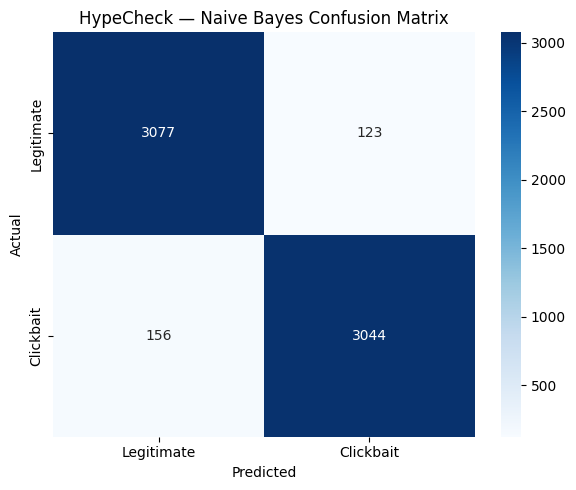

Correctly identified legitimate: 3077
Correctly identified clickbait:  3044
Legitimate wrongly flagged:      123
Clickbait that slipped through:  156


In [7]:
# Plot confusion matrix for best model (Naive Bayes)
best_model = models["Naive Bayes"]
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Clickbait'],
            yticklabels=['Legitimate', 'Clickbait'])
plt.title('HypeCheck — Naive Bayes Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png')
plt.show()

# Print what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"Correctly identified legitimate: {tn}")
print(f"Correctly identified clickbait:  {tp}")
print(f"Legitimate wrongly flagged:      {fp}")
print(f"Clickbait that slipped through:  {fn}")

In [8]:
# Save Naive Bayes as final model
best_model = models["Naive Bayes"]
joblib.dump(best_model, '../model/model.pkl')
print("✅ model.pkl saved!")

# Verify it works by loading and testing
loaded_model = joblib.load('../model/model.pkl')
test_headlines = [
    "You Won't Believe What This Celebrity Did Next!!",
    "India raises interest rates by 0.25% amid inflation concerns"
]

for headline in test_headlines:
    pred = loaded_model.predict([headline])[0]
    label = "🚨 CLICKBAIT" if pred == 1 else "✅ LEGITIMATE"
    print(f"{label} → {headline}")

✅ model.pkl saved!
🚨 CLICKBAIT → You Won't Believe What This Celebrity Did Next!!
✅ LEGITIMATE → India raises interest rates by 0.25% amid inflation concerns
